# Libraries & Dependencies

In [1]:
import pandas as pd
import numpy as np

# Dataset Loading & Description 

In [2]:
df = pd.read_csv("/kaggle/input/datasets/marryammohammed/nasa-battery-cycle-level-dataset/NASA Battery Cycle Level Dataset.csv")

In [3]:
df.tail()

,source_file,battery_id,test_id,uid,start_time,ambient_temperature,Capacity,Re,Rct,Voltage_measured_mean,...,Current_load_range,Voltage_load_range,Time_range,duration_seconds,cycle_number,SOH,initial_capacity,SOH_relative,RUL_cycles,health_class
2764,07302.csv,B0056,240,7302,[2010. 9. 29. 19. 50. ...,4,1.130219,NaN,NaN,3.360501,...,1.998,4.197,2345.000,2345.000,98,0.565110,0.785278,1.439260,4,Degraded
2765,07304.csv,B0056,242,7304,[2.01e+03 9.00e+00 2.90e+01 2.30e+01 3.30e+01 ...,4,1.125872,NaN,NaN,3.353826,...,1.998,4.197,2363.047,2363.047,99,0.562936,0.785278,1.433724,3,Degraded
2766,07306.csv,B0056,244,7306,[2010. 9. 30. 3. 15. ...,4,1.143011,NaN,NaN,3.341679,...,1.998,4.197,2316.687,2316.687,100,0.571505,0.785278,1.455549,2,Degraded
2767,07310.csv,B0056,248,7310,[2010. 9. 30. 8. 8. ...,4,1.137273,NaN,NaN,3.345642,...,1.998,4.188,2322.000,2322.000,101,0.568637,0.785278,1.448243,1,Degraded
2768,07312.csv,B0056,250,7312,[2010. 9. 30. 11. 50. ...,4,1.129059,NaN,NaN,3.349642,...,1.998,4.197,2357.687,2357.687,102,0.564530,0.785278,1.437782,0,Degraded


In [4]:
len(df)

2769

In [5]:
df.isna().sum()

source_file                      0
battery_id                       0
test_id                          0
uid                              0
start_time                       0
ambient_temperature              0
Capacity                         0
Re                            2769
Rct                           2769
Voltage_measured_mean            0
Voltage_measured_std             0
Voltage_measured_min             0
Voltage_measured_max             0
Voltage_measured_first           0
Voltage_measured_last            0
Current_measured_mean            0
Current_measured_std             0
Current_measured_min             0
Current_measured_max             0
Current_measured_first           0
Current_measured_last            0
Temperature_measured_mean        0
Temperature_measured_std         0
Temperature_measured_min         0
Temperature_measured_max         0
Temperature_measured_first       0
Temperature_measured_last        0
Current_load_mean                0
Current_load_std    

# Data Preprocessing & Description:

In [6]:
df = df.dropna(axis=1, how='all')
cols_to_drop = [
    'source_file',      
    'uid',               
    'start_time',        
    'initial_capacity',
    'SOH_relative',      
]
df = df.drop(columns=cols_to_drop)

In [7]:
df.isna().sum()

battery_id                    0
test_id                       0
ambient_temperature           0
Capacity                      0
Voltage_measured_mean         0
Voltage_measured_std          0
Voltage_measured_min          0
Voltage_measured_max          0
Voltage_measured_first        0
Voltage_measured_last         0
Current_measured_mean         0
Current_measured_std          0
Current_measured_min          0
Current_measured_max          0
Current_measured_first        0
Current_measured_last         0
Temperature_measured_mean     0
Temperature_measured_std      0
Temperature_measured_min      0
Temperature_measured_max      0
Temperature_measured_first    0
Temperature_measured_last     0
Current_load_mean             0
Current_load_std              0
Current_load_min              0
Current_load_max              0
Current_load_first            0
Current_load_last             0
Voltage_load_mean             0
Voltage_load_std              0
Voltage_load_min              0
Voltage_

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2769 entries, 0 to 2768
Data columns (total 52 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   battery_id                  2769 non-null   object 
 1   test_id                     2769 non-null   int64  
 2   ambient_temperature         2769 non-null   int64  
 3   Capacity                    2769 non-null   float64
 4   Voltage_measured_mean       2769 non-null   float64
 5   Voltage_measured_std        2769 non-null   float64
 6   Voltage_measured_min        2769 non-null   float64
 7   Voltage_measured_max        2769 non-null   float64
 8   Voltage_measured_first      2769 non-null   float64
 9   Voltage_measured_last       2769 non-null   float64
 10  Current_measured_mean       2769 non-null   float64
 11  Current_measured_std        2769 non-null   float64
 12  Current_measured_min        2769 non-null   float64
 13  Current_measured_max        2769 

# Numerical Summaries

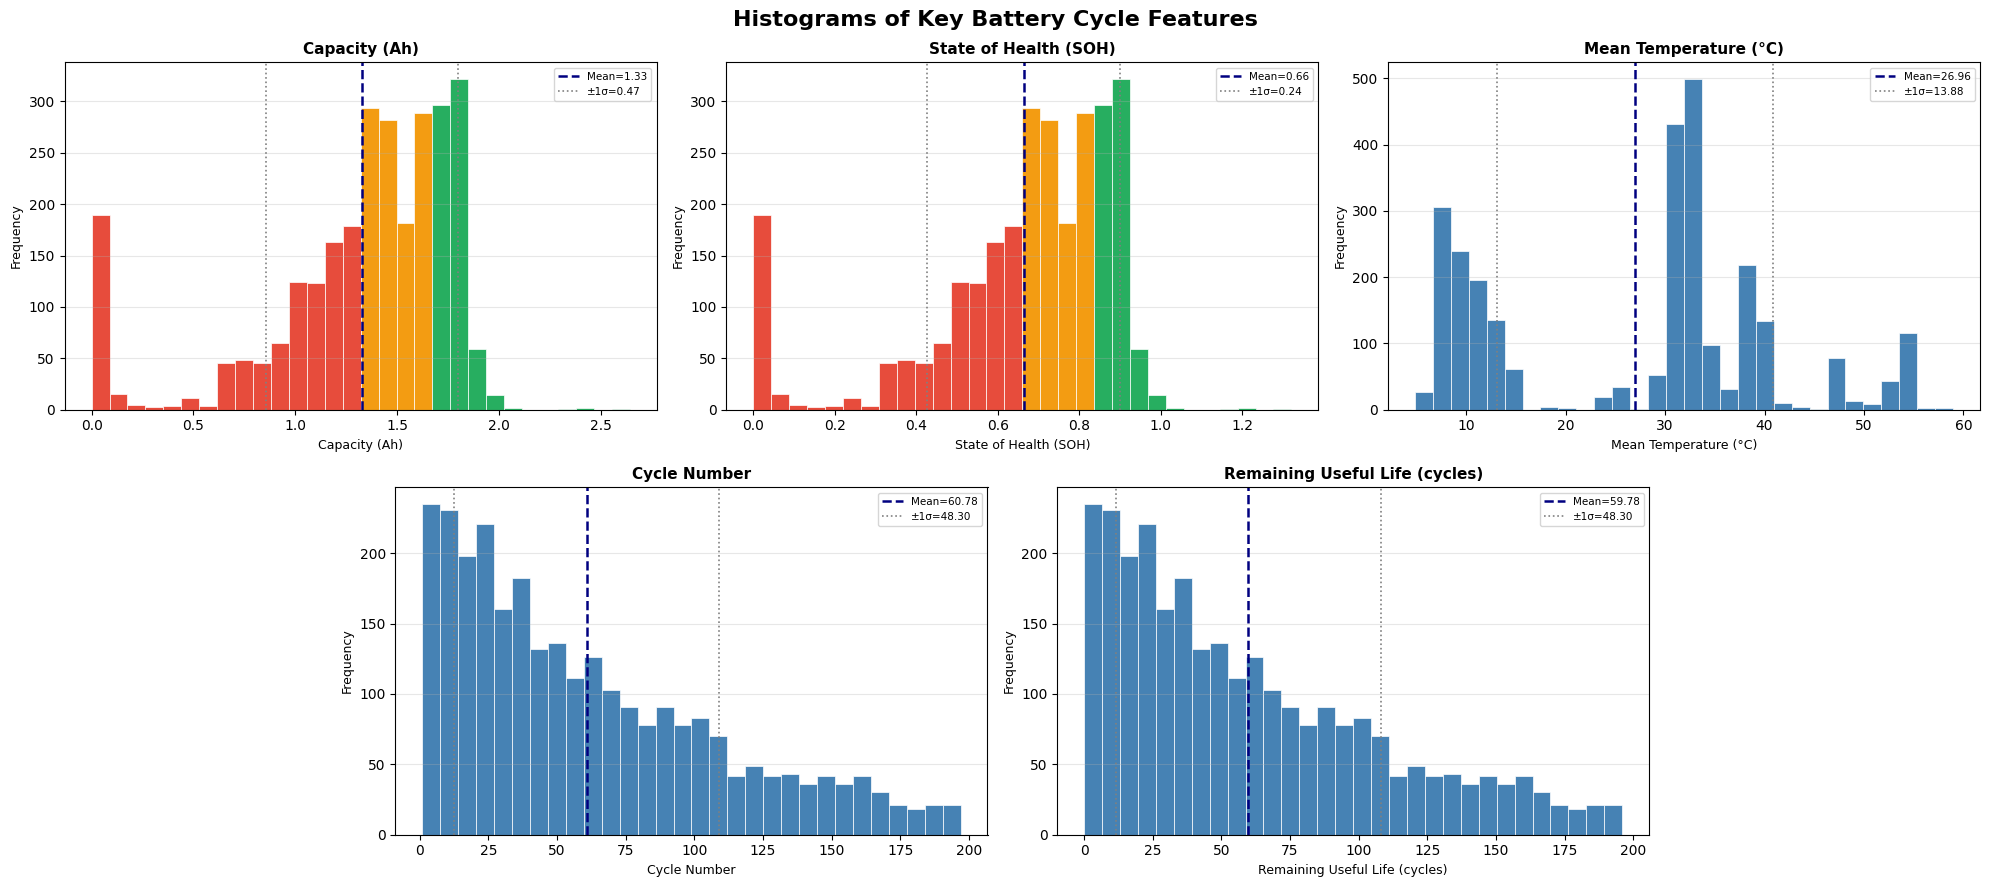

In [9]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

hist_cols = {
    'Capacity':                 'Capacity (Ah)',
    'SOH':                      'State of Health (SOH)',
    'Temperature_measured_mean':'Mean Temperature (°C)',
    'cycle_number':             'Cycle Number',
    'RUL_cycles':               'Remaining Useful Life (cycles)'
}

fig = plt.figure(figsize=(20, 9))
fig.suptitle(
    'Histograms of Key Battery Cycle Features',
    fontsize=16,
    fontweight='bold',
    y=0.98
)

gs = gridspec.GridSpec(2, 6, figure=fig)

axes = [
    fig.add_subplot(gs[0, 0:2]),  
    fig.add_subplot(gs[0, 2:4]),
    fig.add_subplot(gs[0, 4:6]),
    fig.add_subplot(gs[1, 1:3]),  
    fig.add_subplot(gs[1, 3:5])   
]

for ax, (col, label) in zip(axes, hist_cols.items()):
    data = df[col].dropna()

    n, bins, patches = ax.hist(
        data,
        bins=30,
        color='steelblue',
        edgecolor='white',
        linewidth=0.5
    )

    if col in ['Capacity', 'SOH']:
        for patch, left in zip(patches, bins[:-1]):
            if left < data.quantile(0.33):
                patch.set_facecolor('#e74c3c')
            elif left < data.quantile(0.66):
                patch.set_facecolor('#f39c12')
            else:
                patch.set_facecolor('#27ae60')

    ax.axvline(
        data.mean(),
        color='navy',
        linestyle='--',
        linewidth=1.8,
        label=f'Mean={data.mean():.2f}'
    )

    ax.axvline(
        data.mean() + data.std(),
        color='gray',
        linestyle=':',
        linewidth=1.2,
        label=f'±1σ={data.std():.2f}'
    )

    ax.axvline(
        data.mean() - data.std(),
        color='gray',
        linestyle=':',
        linewidth=1.2
    )

    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel('Frequency', fontsize=9)
    ax.legend(fontsize=7.5)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('histograms.png', dpi=400, bbox_inches='tight')
plt.show()

In [10]:
summary_cols = [
    'Capacity',
    'Voltage_measured_mean', 'Voltage_measured_std', 'Voltage_measured_min', 'Voltage_measured_max',
    'Current_measured_mean', 'Current_measured_std',
    'Temperature_measured_mean', 'Temperature_measured_std',
    'duration_seconds', 'cycle_number',
    'SOH', 'RUL_cycles'
]

summary = pd.DataFrame({
    'Mean':     df[summary_cols].mean(),
    'Variance': df[summary_cols].var(),
    'Std Dev':  df[summary_cols].std(),
    'Min':      df[summary_cols].min(),
    'Max':      df[summary_cols].max(),
    'Count':    df[summary_cols].count()
}).round(4)

print("=" * 65)
print("        Numerical Summary of Key Battery Cycle Features")
print("=" * 65)
print(summary.to_string())
print("=" * 65)
print(f"\nDataset shape: {df.shape[0]} cycles × {df.shape[1]} features")

        Numerical Summary of Key Battery Cycle Features
                                Mean      Variance    Std Dev      Min        Max  Count
Capacity                      1.3265  2.233000e-01     0.4725   0.0000     2.6401   2769
Voltage_measured_mean         3.4313  3.940000e-02     0.1985   2.5300     4.4526   2769
Voltage_measured_std          0.3019  7.000000e-03     0.0838   0.1365     1.3699   2769
Voltage_measured_min          2.3214  9.550000e-02     0.3090   0.1927     3.8384   2769
Voltage_measured_max          4.1855  1.400000e-03     0.0374   3.6772     4.5424   2769
Current_measured_mean        -1.7288  6.107000e-01     0.7815  -3.9765    -0.0293   2769
Current_measured_std          0.7665  4.011000e-01     0.6333   0.0557     2.1031   2769
Temperature_measured_mean    26.9613  1.926447e+02    13.8797   4.8578    58.9548   2769
Temperature_measured_std      3.8518  5.089600e+00     2.2560   0.2857    11.1210   2769
duration_seconds           3227.8533  1.928624e+06  13

/tmp/ipykernel_57/746272922.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(groups, labels=labels, patch_artist=True,
/tmp/ipykernel_57/746272922.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax2.boxplot(temp_groups, labels=temp_labels, patch_artist=True,
/tmp/ipykernel_57/746272922.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp4 = ax4.boxplot(sensor_z, labels=sensor_names, patch_artist=True,


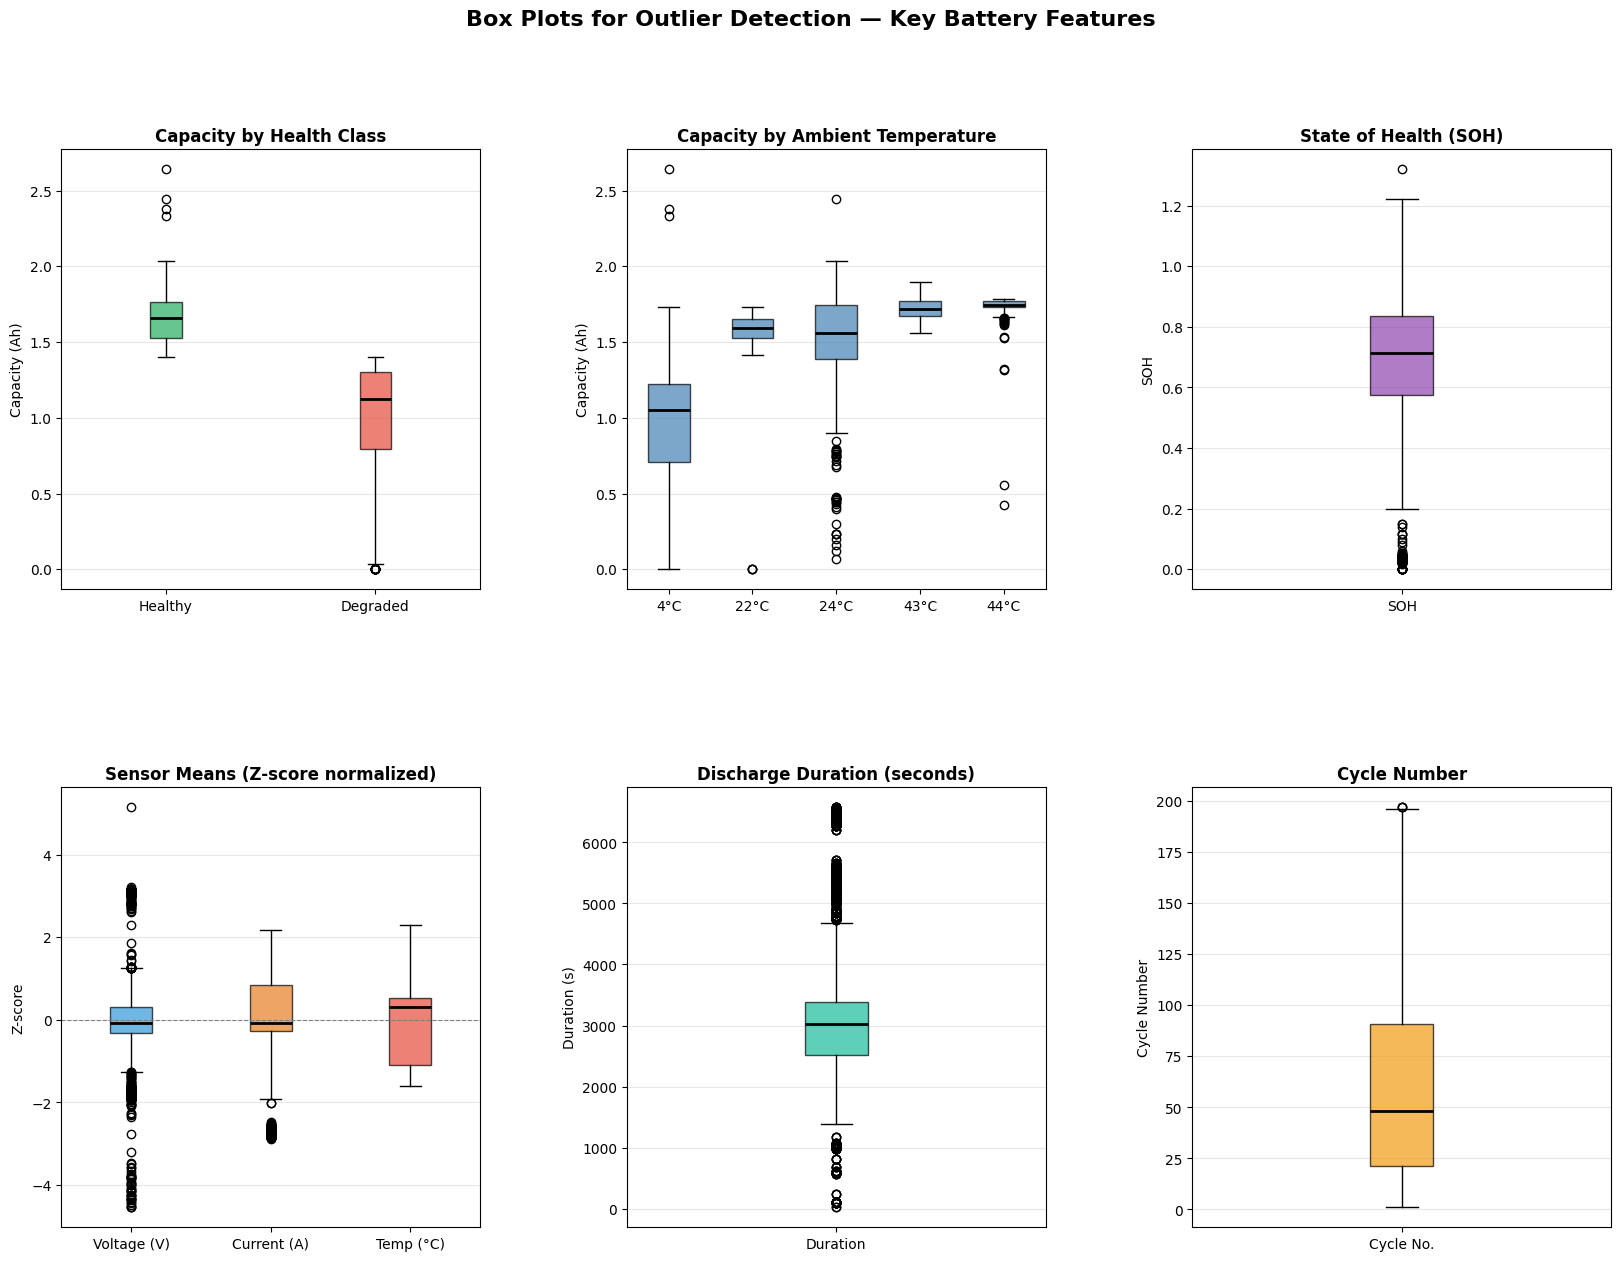


 Outlier Summary (IQR method)
  Capacity                            →  214 outliers (7.7%)
  SOH                                 →  214 outliers (7.7%)
  Voltage_measured_mean               →  352 outliers (12.7%)
  Current_measured_mean               →  206 outliers (7.4%)
  Temperature_measured_mean           →    0 outliers (0.0%)
  duration_seconds                    →  651 outliers (23.5%)


In [11]:
fig = plt.figure(figsize=(20, 14))
fig.suptitle('Box Plots for Outlier Detection — Key Battery Features', fontsize=16, fontweight='bold')

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
groups = [df[df['health_class'] == cls]['Capacity'].dropna() for cls in df['health_class'].unique()]
labels = df['health_class'].unique()
bp = ax1.boxplot(groups, labels=labels, patch_artist=True,
                 medianprops=dict(color='black', linewidth=2))
colors = ['#27ae60', '#e74c3c', '#f39c12']
for patch, color in zip(bp['boxes'], colors[:len(groups)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax1.set_title('Capacity by Health Class', fontweight='bold')
ax1.set_ylabel('Capacity (Ah)')
ax1.grid(axis='y', alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
temp_groups = [df[df['ambient_temperature'] == t]['Capacity'].dropna()
               for t in sorted(df['ambient_temperature'].unique())]
temp_labels  = [f"{t}°C" for t in sorted(df['ambient_temperature'].unique())]
bp2 = ax2.boxplot(temp_groups, labels=temp_labels, patch_artist=True,
                  medianprops=dict(color='black', linewidth=2))
for patch in bp2['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.7)
ax2.set_title('Capacity by Ambient Temperature', fontweight='bold')
ax2.set_ylabel('Capacity (Ah)')
ax2.grid(axis='y', alpha=0.3)

ax3 = fig.add_subplot(gs[0, 2])
bp3 = ax3.boxplot(df['SOH'].dropna(), patch_artist=True,
                  medianprops=dict(color='black', linewidth=2))
bp3['boxes'][0].set_facecolor('#8e44ad')
bp3['boxes'][0].set_alpha(0.7)
ax3.set_title('State of Health (SOH)', fontweight='bold')
ax3.set_ylabel('SOH')
ax3.set_xticks([1]); ax3.set_xticklabels(['SOH'])
ax3.grid(axis='y', alpha=0.3)

ax4 = fig.add_subplot(gs[1, 0])
sensor_cols  = ['Voltage_measured_mean', 'Current_measured_mean', 'Temperature_measured_mean']
sensor_names = ['Voltage (V)', 'Current (A)', 'Temp (°C)']
sensor_data  = [df[c].dropna() for c in sensor_cols]

sensor_z = [(d - d.mean()) / d.std() for d in sensor_data]
bp4 = ax4.boxplot(sensor_z, labels=sensor_names, patch_artist=True,
                  medianprops=dict(color='black', linewidth=2))
sensor_colors = ['#3498db', '#e67e22', '#e74c3c']
for patch, color in zip(bp4['boxes'], sensor_colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax4.set_title('Sensor Means (Z-score normalized)', fontweight='bold')
ax4.set_ylabel('Z-score')
ax4.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax4.grid(axis='y', alpha=0.3)

ax5 = fig.add_subplot(gs[1, 1])
bp5 = ax5.boxplot(df['duration_seconds'].dropna(), patch_artist=True,
                  medianprops=dict(color='black', linewidth=2))
bp5['boxes'][0].set_facecolor('#1abc9c'); bp5['boxes'][0].set_alpha(0.7)
ax5.set_title('Discharge Duration (seconds)', fontweight='bold')
ax5.set_ylabel('Duration (s)')
ax5.set_xticks([1]); ax5.set_xticklabels(['Duration'])
ax5.grid(axis='y', alpha=0.3)

ax6 = fig.add_subplot(gs[1, 2])
bp6 = ax6.boxplot(df['cycle_number'].dropna(), patch_artist=True,
                  medianprops=dict(color='black', linewidth=2))
bp6['boxes'][0].set_facecolor('#f39c12'); bp6['boxes'][0].set_alpha(0.7)
ax6.set_title('Cycle Number', fontweight='bold')
ax6.set_ylabel('Cycle Number')
ax6.set_xticks([1]); ax6.set_xticklabels(['Cycle No.'])
ax6.grid(axis='y', alpha=0.3)

plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Outlier Summary (IQR method)")
for col in ['Capacity', 'SOH', 'Voltage_measured_mean',
            'Current_measured_mean', 'Temperature_measured_mean', 'duration_seconds']:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    print(f"  {col:<35} → {len(outliers):>4} outliers ({len(outliers)/len(df)*100:.1f}%)")

# Statistical Inference

1) ANOVA: Does Ambient Temperature Affect Capacity?

  H0: Ambient temperature has NO effect on Capacity
  H1: Ambient temperature SIGNIFICANTLY affects Capacity
  Groups tested : [np.int64(4), np.int64(22), np.int64(24), np.int64(43), np.int64(44)]
  Temp    4°C    → Mean Capacity = 0.9040 Ah  (n=1006)
  Temp   22°C    → Mean Capacity = 1.5512 Ah  (n=123)
  Temp   24°C    → Mean Capacity = 1.5407 Ah  (n=1375)
  Temp   43°C    → Mean Capacity = 1.7212 Ah  (n=160)
  Temp   44°C    → Mean Capacity = 1.7053 Ah  (n=105)
------------------------------------------------------------
  F-statistic   : 606.4285
  p-value       : 0.000000
------------------------------------------------------------
REJECT H0 — Temperature significantly affects Capacity (p < 0.05)


/tmp/ipykernel_57/1485096768.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(groups, labels=[f'{t}°C' for t in temps], patch_artist=True,


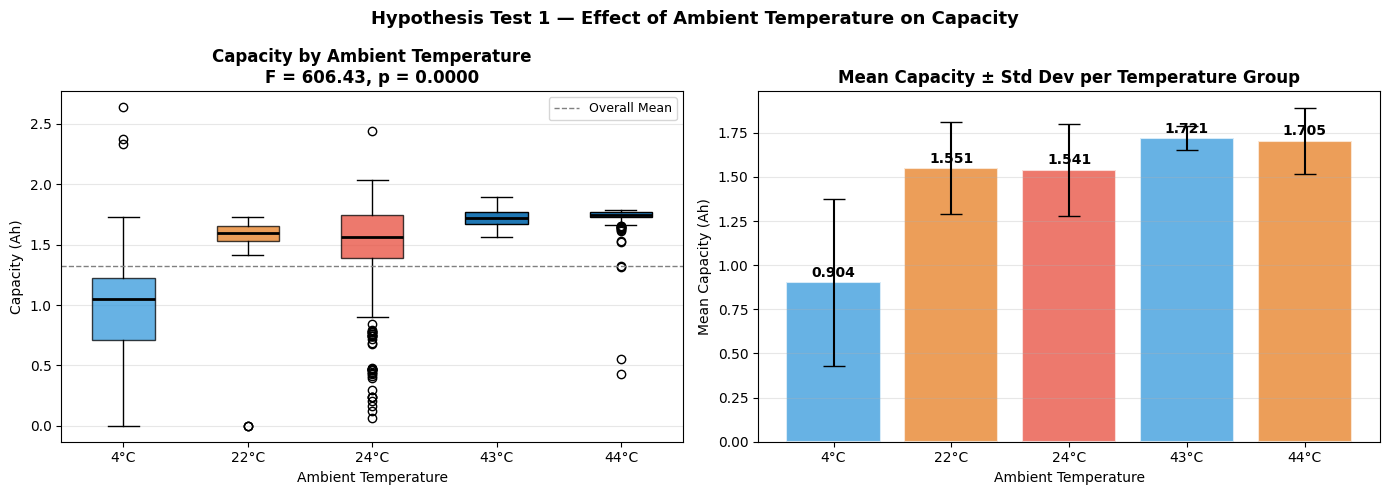

In [12]:
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np

temps  = sorted(df['ambient_temperature'].unique())
groups = [df[df['ambient_temperature'] == t]['Capacity'].dropna() for t in temps]

f_stat, p_value = stats.f_oneway(*groups)

print("=" * 60)
print("  H0: Ambient temperature has NO effect on Capacity")
print("  H1: Ambient temperature SIGNIFICANTLY affects Capacity")
print("=" * 60)
print(f"  Groups tested : {temps}")
for t, g in zip(temps, groups):
    print(f"  Temp {t:>4}°C    → Mean Capacity = {g.mean():.4f} Ah  (n={len(g)})")
print("-" * 60)
print(f"  F-statistic   : {f_stat:.4f}")
print(f"  p-value       : {p_value:.6f}")
print("-" * 60)
if p_value < 0.05:
    print("REJECT H0 — Temperature significantly affects Capacity (p < 0.05)")
else:
    print(" FAIL TO REJECT H0 — No significant effect detected (p ≥ 0.05)")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Hypothesis Test 1 — Effect of Ambient Temperature on Capacity',
             fontsize=13, fontweight='bold')

colors = ['#3498db', '#e67e22', '#e74c3c']

axes[0].boxplot(groups, labels=[f'{t}°C' for t in temps], patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
for patch, c in zip(axes[0].patches, colors):
    patch.set_facecolor(c); patch.set_alpha(0.75)
axes[0].set_title(f'Capacity by Ambient Temperature\nF = {f_stat:.2f}, p = {p_value:.4f}',
                  fontweight='bold')
axes[0].set_xlabel('Ambient Temperature')
axes[0].set_ylabel('Capacity (Ah)')
axes[0].grid(axis='y', alpha=0.3)
axes[0].axhline(df['Capacity'].mean(), color='gray', linestyle='--',
                linewidth=1, label='Overall Mean')
axes[0].legend(fontsize=9)

means = [g.mean() for g in groups]
stds  = [g.std()  for g in groups]
bars  = axes[1].bar([f'{t}°C' for t in temps], means, yerr=stds,
                    color=colors, alpha=0.75, edgecolor='white',
                    capsize=8, linewidth=1.5)
axes[1].set_title('Mean Capacity ± Std Dev per Temperature Group', fontweight='bold')
axes[1].set_xlabel('Ambient Temperature')
axes[1].set_ylabel('Mean Capacity (Ah)')
axes[1].grid(axis='y', alpha=0.3)
for bar, mean in zip(bars, means):
    axes[1].text(bar.get_x() + bar.get_width()/2, mean + 0.03,
                 f'{mean:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

3) t-test: Does Health Class Affect Capacity?

  H0: Health class has NO effect on Capacity
  H1: Health class SIGNIFICANTLY affects Capacity
  Healthy  → Mean = 1.6504 Ah | Std = 0.1466 | n = 1476
  Degraded → Mean = 0.9569 Ah | Std = 0.4441 | n = 1293
------------------------------------------------------------
  t-test   t = 53.64,  p = 0.000000
------------------------------------------------------------
REJECT H0 — Health class significantly affects Capacity


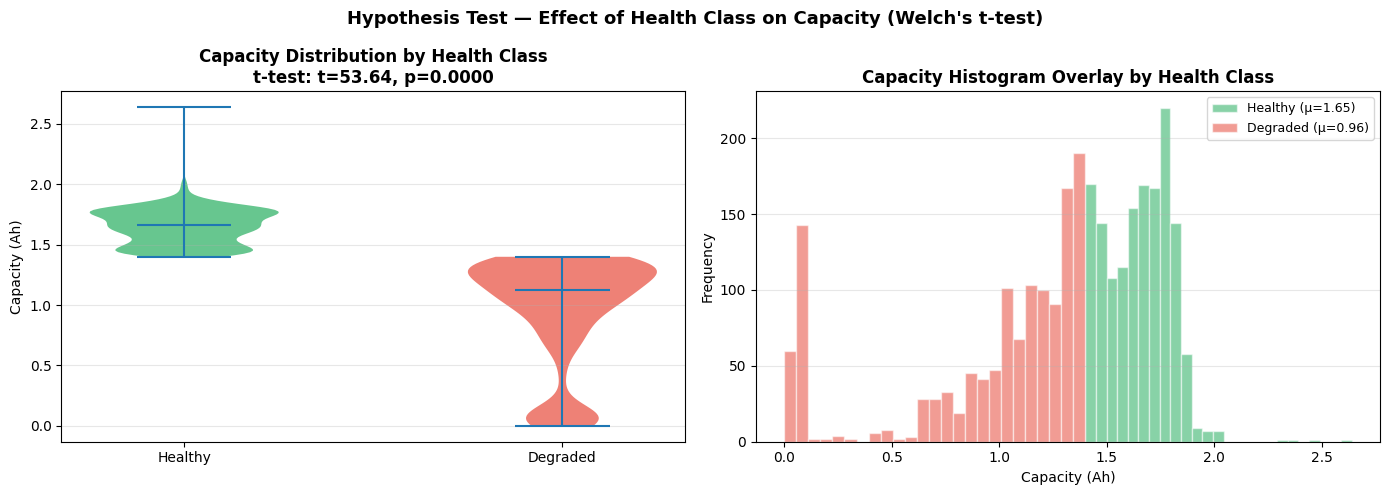

In [13]:
from scipy.stats import ttest_ind

healthy  = df[df['health_class'] == 'Healthy']['Capacity'].dropna()
degraded = df[df['health_class'] == 'Degraded']['Capacity'].dropna()

t_stat, p_ttest = ttest_ind(healthy, degraded, equal_var=False) 

print("  H0: Health class has NO effect on Capacity")
print("  H1: Health class SIGNIFICANTLY affects Capacity")
print(f"  Healthy  → Mean = {healthy.mean():.4f} Ah | Std = {healthy.std():.4f} | n = {len(healthy)}")
print(f"  Degraded → Mean = {degraded.mean():.4f} Ah | Std = {degraded.std():.4f} | n = {len(degraded)}")
print("-" * 60)
print(f"  t-test   t = {t_stat:.2f},  p = {p_ttest:.6f}")
print("-" * 60)
if p_ttest < 0.05:
    print("REJECT H0 — Health class significantly affects Capacity")
else:
    print("FAIL TO REJECT H0 — No significant difference found")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Hypothesis Test — Effect of Health Class on Capacity (Welch\'s t-test)',
             fontsize=13, fontweight='bold')

colors = ['#27ae60', '#e74c3c']
groups = [healthy, degraded]
labels = ['Healthy', 'Degraded']

parts = axes[0].violinplot(groups, showmedians=True, showextrema=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[i]); pc.set_alpha(0.7)
axes[0].set_xticks([1, 2])
axes[0].set_xticklabels(labels)
axes[0].set_title(f'Capacity Distribution by Health Class\n'
                  f't-test: t={t_stat:.2f}, p={p_ttest:.4f}', fontweight='bold')
axes[0].set_ylabel('Capacity (Ah)')
axes[0].grid(axis='y', alpha=0.3)

for grp, color, lbl in zip(groups, colors, labels):
    axes[1].hist(grp, bins=25, alpha=0.55, color=color,
                 label=f'{lbl} (μ={grp.mean():.2f})', edgecolor='white')
axes[1].set_title('Capacity Histogram Overlay by Health Class', fontweight='bold')
axes[1].set_xlabel('Capacity (Ah)')
axes[1].set_ylabel('Frequency')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Confidence Intervals

Statistic  Estimate  CI Lower  CI Upper  CI Width
     Mean   1.32654   1.30894   1.34415   0.03521
 Variance   0.22327   0.21196   0.23552   0.02356
  Std Dev   0.47252   0.46039   0.48530   0.02491

Engineering Risk — Mean: HIGH  |  Variability: HIGH  |  CI Width: MOD


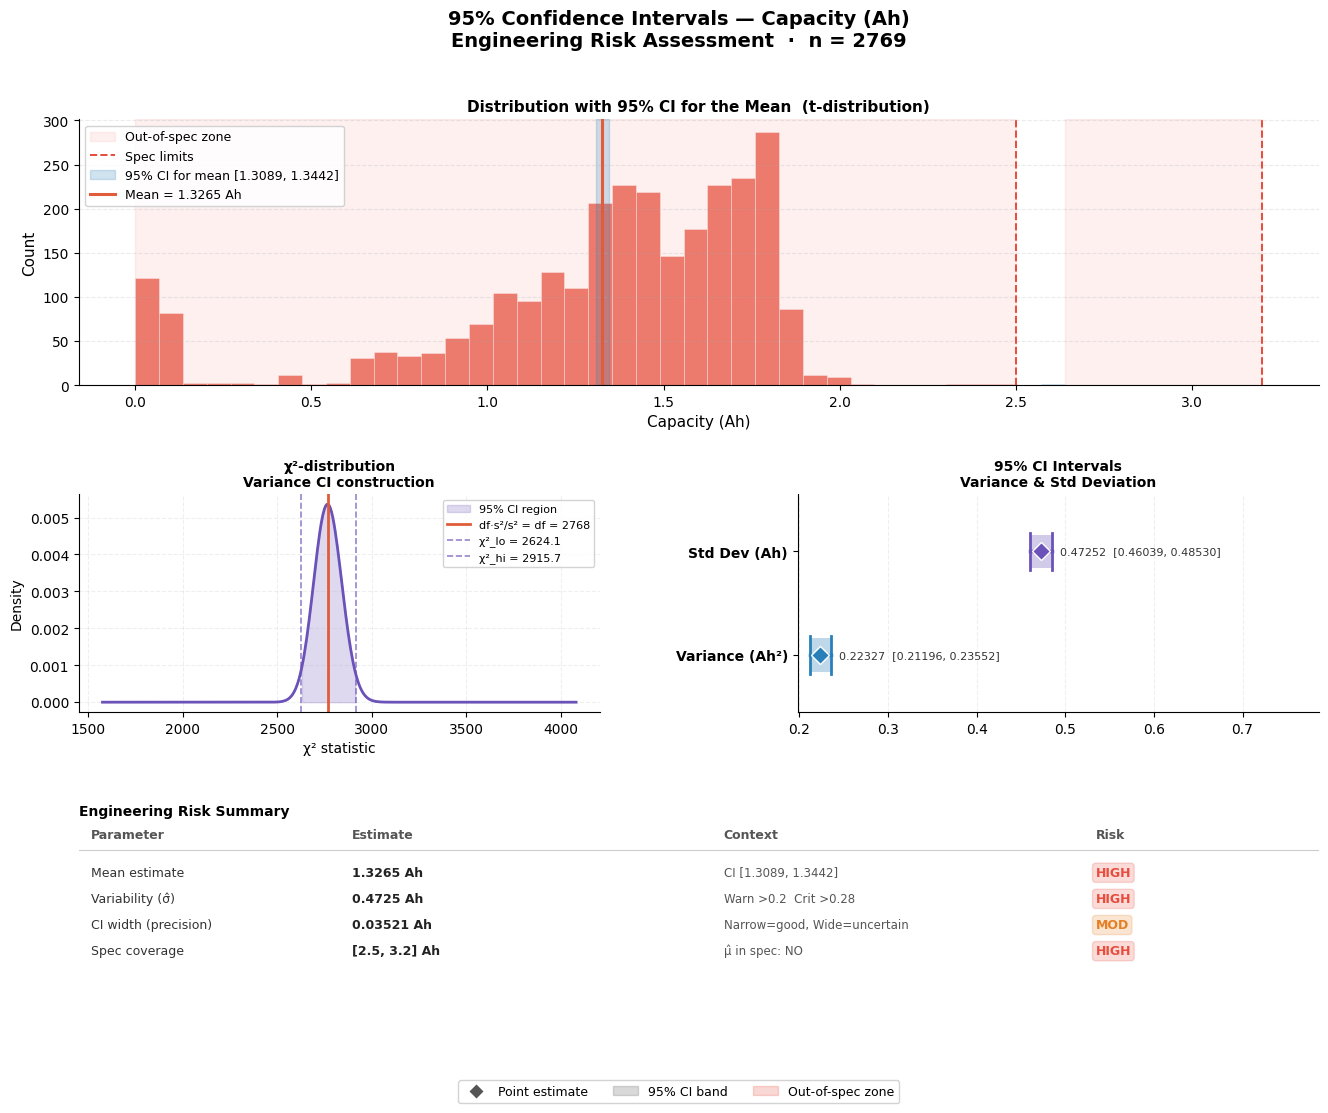

In [14]:
from scipy import stats
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

CONFIDENCE  = 0.95
ALPHA       = 1 - CONFIDENCE
COL         = 'Capacity'         
LABEL       = 'Capacity (Ah)'
COLOR       = '#2980b9'
SPEC_MIN    = 2.5                 
SPEC_MAX    = 3.2              
STD_WARN    = 0.20                
STD_CRIT    = 0.28                

series = df[COL].dropna()
n      = len(series)
mu     = series.mean()
s      = series.std(ddof=1)
s2     = s ** 2
se     = stats.sem(series)
dof    = n - 1

t_crit  = stats.t.ppf(1 - ALPHA / 2, df=dof)
margin  = t_crit * se
mean_lo = mu - margin
mean_hi = mu + margin

chi2_lo = stats.chi2.ppf(ALPHA / 2,       df=dof)
chi2_hi = stats.chi2.ppf(1 - ALPHA / 2,  df=dof)
var_lo  = (dof * s2) / chi2_hi
var_hi  = (dof * s2) / chi2_lo
std_lo  = np.sqrt(var_lo)
std_hi  = np.sqrt(var_hi)

mean_risk = ('HIGH'     if mu < SPEC_MIN or mu > SPEC_MAX
             else 'MOD' if (mu - SPEC_MIN < 0.15 or SPEC_MAX - mu < 0.15)
             else 'LOW')
std_risk  = 'HIGH' if s > STD_CRIT else ('MOD' if s > STD_WARN else 'LOW')
ci_width  = mean_hi - mean_lo
width_risk = 'HIGH' if ci_width > 0.05 else ('MOD' if ci_width > 0.025 else 'LOW')

risk_color = {'LOW': '#27ae60', 'MOD': '#e67e22', 'HIGH': '#e74c3c'}

ci_df = pd.DataFrame({
    'Statistic':    ['Mean',       'Variance',   'Std Dev'],
    'Estimate':     [mu,           s2,           s],
    'CI Lower':     [mean_lo,      var_lo,       std_lo],
    'CI Upper':     [mean_hi,      var_hi,       std_hi],
    'CI Width':     [mean_hi-mean_lo, var_hi-var_lo, std_hi-std_lo],
})
print(ci_df.to_string(index=False, float_format='%.5f'))
print(f"\nEngineering Risk — Mean: {mean_risk}  |  Variability: {std_risk}  |  CI Width: {width_risk}")

fig = plt.figure(figsize=(16, 11))
fig.suptitle(
    f'95% Confidence Intervals — {LABEL}\n'
    f'Engineering Risk Assessment  ·  n = {n}',
    fontsize=14, fontweight='bold', y=0.98
)
gs = GridSpec(3, 2, figure=fig, hspace=0.52, wspace=0.38,
              height_ratios=[2.2, 1.8, 1.2])

ax_hist  = fig.add_subplot(gs[0, :])     
ax_chi2  = fig.add_subplot(gs[1, 0])   
ax_intv  = fig.add_subplot(gs[1, 1])   
ax_risk  = fig.add_subplot(gs[2, :])   

ax = ax_hist
bins = np.linspace(series.min(), series.max(), 40)

bar_col = [('#e74c3c' if (b < SPEC_MIN or b + (bins[1]-bins[0]) > SPEC_MAX)
             else COLOR)
           for b in bins[:-1]]

n_arr, bins_arr, patches = ax.hist(series, bins=bins, edgecolor='white',
                                    linewidth=0.4, color=COLOR, alpha=0.0)
for patch, c in zip(patches, bar_col):
    patch.set_facecolor(c)
    patch.set_alpha(0.72)

ax.axvspan(series.min(), SPEC_MIN, color='#e74c3c', alpha=0.08, label='Out-of-spec zone')
ax.axvspan(SPEC_MAX, series.max(), color='#e74c3c', alpha=0.08)
ax.axvline(SPEC_MIN, color='#e74c3c', lw=1.4, ls='--', label='Spec limits')
ax.axvline(SPEC_MAX, color='#e74c3c', lw=1.4, ls='--')

ax.axvspan(mean_lo, mean_hi, color=COLOR, alpha=0.22, label=f'95% CI for mean [{mean_lo:.4f}, {mean_hi:.4f}]')
ax.axvline(mu, color='#e05c3a', lw=2.2, label=f'Mean = {mu:.4f} Ah')

ax.set_xlabel(LABEL, fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Distribution with 95% CI for the Mean  (t-distribution)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9, framealpha=0.85)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.25, ls='--')

ax = ax_chi2
x_chi2 = np.linspace(max(0.01, chi2_lo * 0.6), chi2_hi * 1.4, 400)
y_chi2 = stats.chi2.pdf(x_chi2, df=dof)

ax.plot(x_chi2, y_chi2, color='#6b52b8', lw=2)
mask_ci = (x_chi2 >= chi2_lo) & (x_chi2 <= chi2_hi)
ax.fill_between(x_chi2, y_chi2, where=mask_ci,
                color='#6b52b8', alpha=0.22, label='95% CI region')

chi2_stat = dof * s2 / s2  
ax.axvline(dof, color='#e05c3a', lw=2, label=f'df·s²/s² = df = {dof}')
ax.axvline(chi2_lo, color='#6b52b8', lw=1.2, ls='--', alpha=0.7, label=f'χ²_lo = {chi2_lo:.1f}')
ax.axvline(chi2_hi, color='#6b52b8', lw=1.2, ls='--', alpha=0.7, label=f'χ²_hi = {chi2_hi:.1f}')

ax.set_xlabel('χ² statistic', fontsize=10)
ax.set_ylabel('Density', fontsize=10)
ax.set_title('χ²-distribution\nVariance CI construction', fontsize=10, fontweight='bold')
ax.legend(fontsize=8, framealpha=0.85)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(alpha=0.2, ls='--')

ax = ax_intv
stats_rows = [
    ('Std Dev (Ah)',   std_lo,  std_hi,  s,   '#6b52b8'),
    ('Variance (Ah²)', var_lo,  var_hi,  s2,  COLOR),
]
y_pos = [1, 0]
for (name, lo, hi, pt, col), yp in zip(stats_rows, y_pos):
    ax.barh(yp, hi - lo, left=lo, height=0.32, color=col, alpha=0.30, zorder=1)
    ax.plot([lo, hi], [yp, yp], '-', color=col, lw=2.5, zorder=2)
    ax.plot([lo, lo], [yp-0.18, yp+0.18], '-', color=col, lw=2, zorder=3)
    ax.plot([hi, hi], [yp-0.18, yp+0.18], '-', color=col, lw=2, zorder=3)
    ax.plot(pt, yp, 'D', color=col, ms=9, zorder=5,
            markeredgecolor='white', markeredgewidth=1)
    pad = (hi - lo) * 0.04
    ax.text(hi + pad, yp,
            f"  {pt:.5f}  [{lo:.5f}, {hi:.5f}]",
            va='center', ha='left', fontsize=8, color='#333')

ax.set_yticks(y_pos)
ax.set_yticklabels([r[0] for r in stats_rows], fontsize=10, fontweight='bold')
ax.set_ylim(-0.55, 1.55)
x_range = max(var_hi, std_hi) - min(var_lo, std_lo)
ax.set_xlim(min(var_lo, std_lo) - x_range * 0.05,
            max(var_hi, std_hi) + x_range * 1.1)
ax.set_title('95% CI Intervals\nVariance & Std Deviation', fontsize=10, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', alpha=0.2, ls='--')

ax = ax_risk
ax.axis('off')

summary = [
    ('Mean estimate',      f'{mu:.4f} Ah',         f'CI [{mean_lo:.4f}, {mean_hi:.4f}]',  mean_risk),
    ('Variability (σ̂)',    f'{s:.4f} Ah',           f'Warn >{STD_WARN}  Crit >{STD_CRIT}', std_risk),
    ('CI width (precision)', f'{ci_width:.5f} Ah', f'Narrow=good, Wide=uncertain',          width_risk),
    ('Spec coverage',      f'[{SPEC_MIN}, {SPEC_MAX}] Ah', f'μ̂ in spec: {"YES" if SPEC_MIN<=mu<=SPEC_MAX else "NO"}', mean_risk),
]

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
col_x = [0.01, 0.22, 0.52, 0.82]
headers = ['Parameter', 'Estimate', 'Context', 'Risk']
for x, h in zip(col_x, headers):
    ax.text(x, 0.88, h, fontsize=9, fontweight='bold', color='#555',
            transform=ax.transAxes)
ax.plot([0, 1], [0.80, 0.80], color='#ccc', lw=0.8, transform=ax.transAxes)


for i, (param, est, ctx, risk) in enumerate(summary):
    y = 0.62 - i * 0.18
    ax.text(col_x[0], y, param, fontsize=9,  color='#333', transform=ax.transAxes)
    ax.text(col_x[1], y, est,   fontsize=9,  color='#222', fontweight='bold', transform=ax.transAxes)
    ax.text(col_x[2], y, ctx,   fontsize=8.5,color='#555', transform=ax.transAxes)
    bbox = dict(boxstyle='round,pad=0.25', fc=risk_color[risk], alpha=0.20, ec=risk_color[risk])
    ax.text(col_x[3], y, risk, fontsize=9, color=risk_color[risk],
            fontweight='bold', transform=ax.transAxes, bbox=bbox)

ax.set_title('Engineering Risk Summary', fontsize=10, fontweight='bold', loc='left', pad=4)

legend_handles = [
    plt.Line2D([0],[0], marker='D', color='w', markerfacecolor='#555', ms=8, label='Point estimate'),
    mpatches.Patch(color='#555', alpha=0.22, label='95% CI band'),
    mpatches.Patch(color='#e74c3c', alpha=0.22, label='Out-of-spec zone'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=3,
           fontsize=9, framealpha=0.85, bbox_to_anchor=(0.5, -0.02))

plt.show()